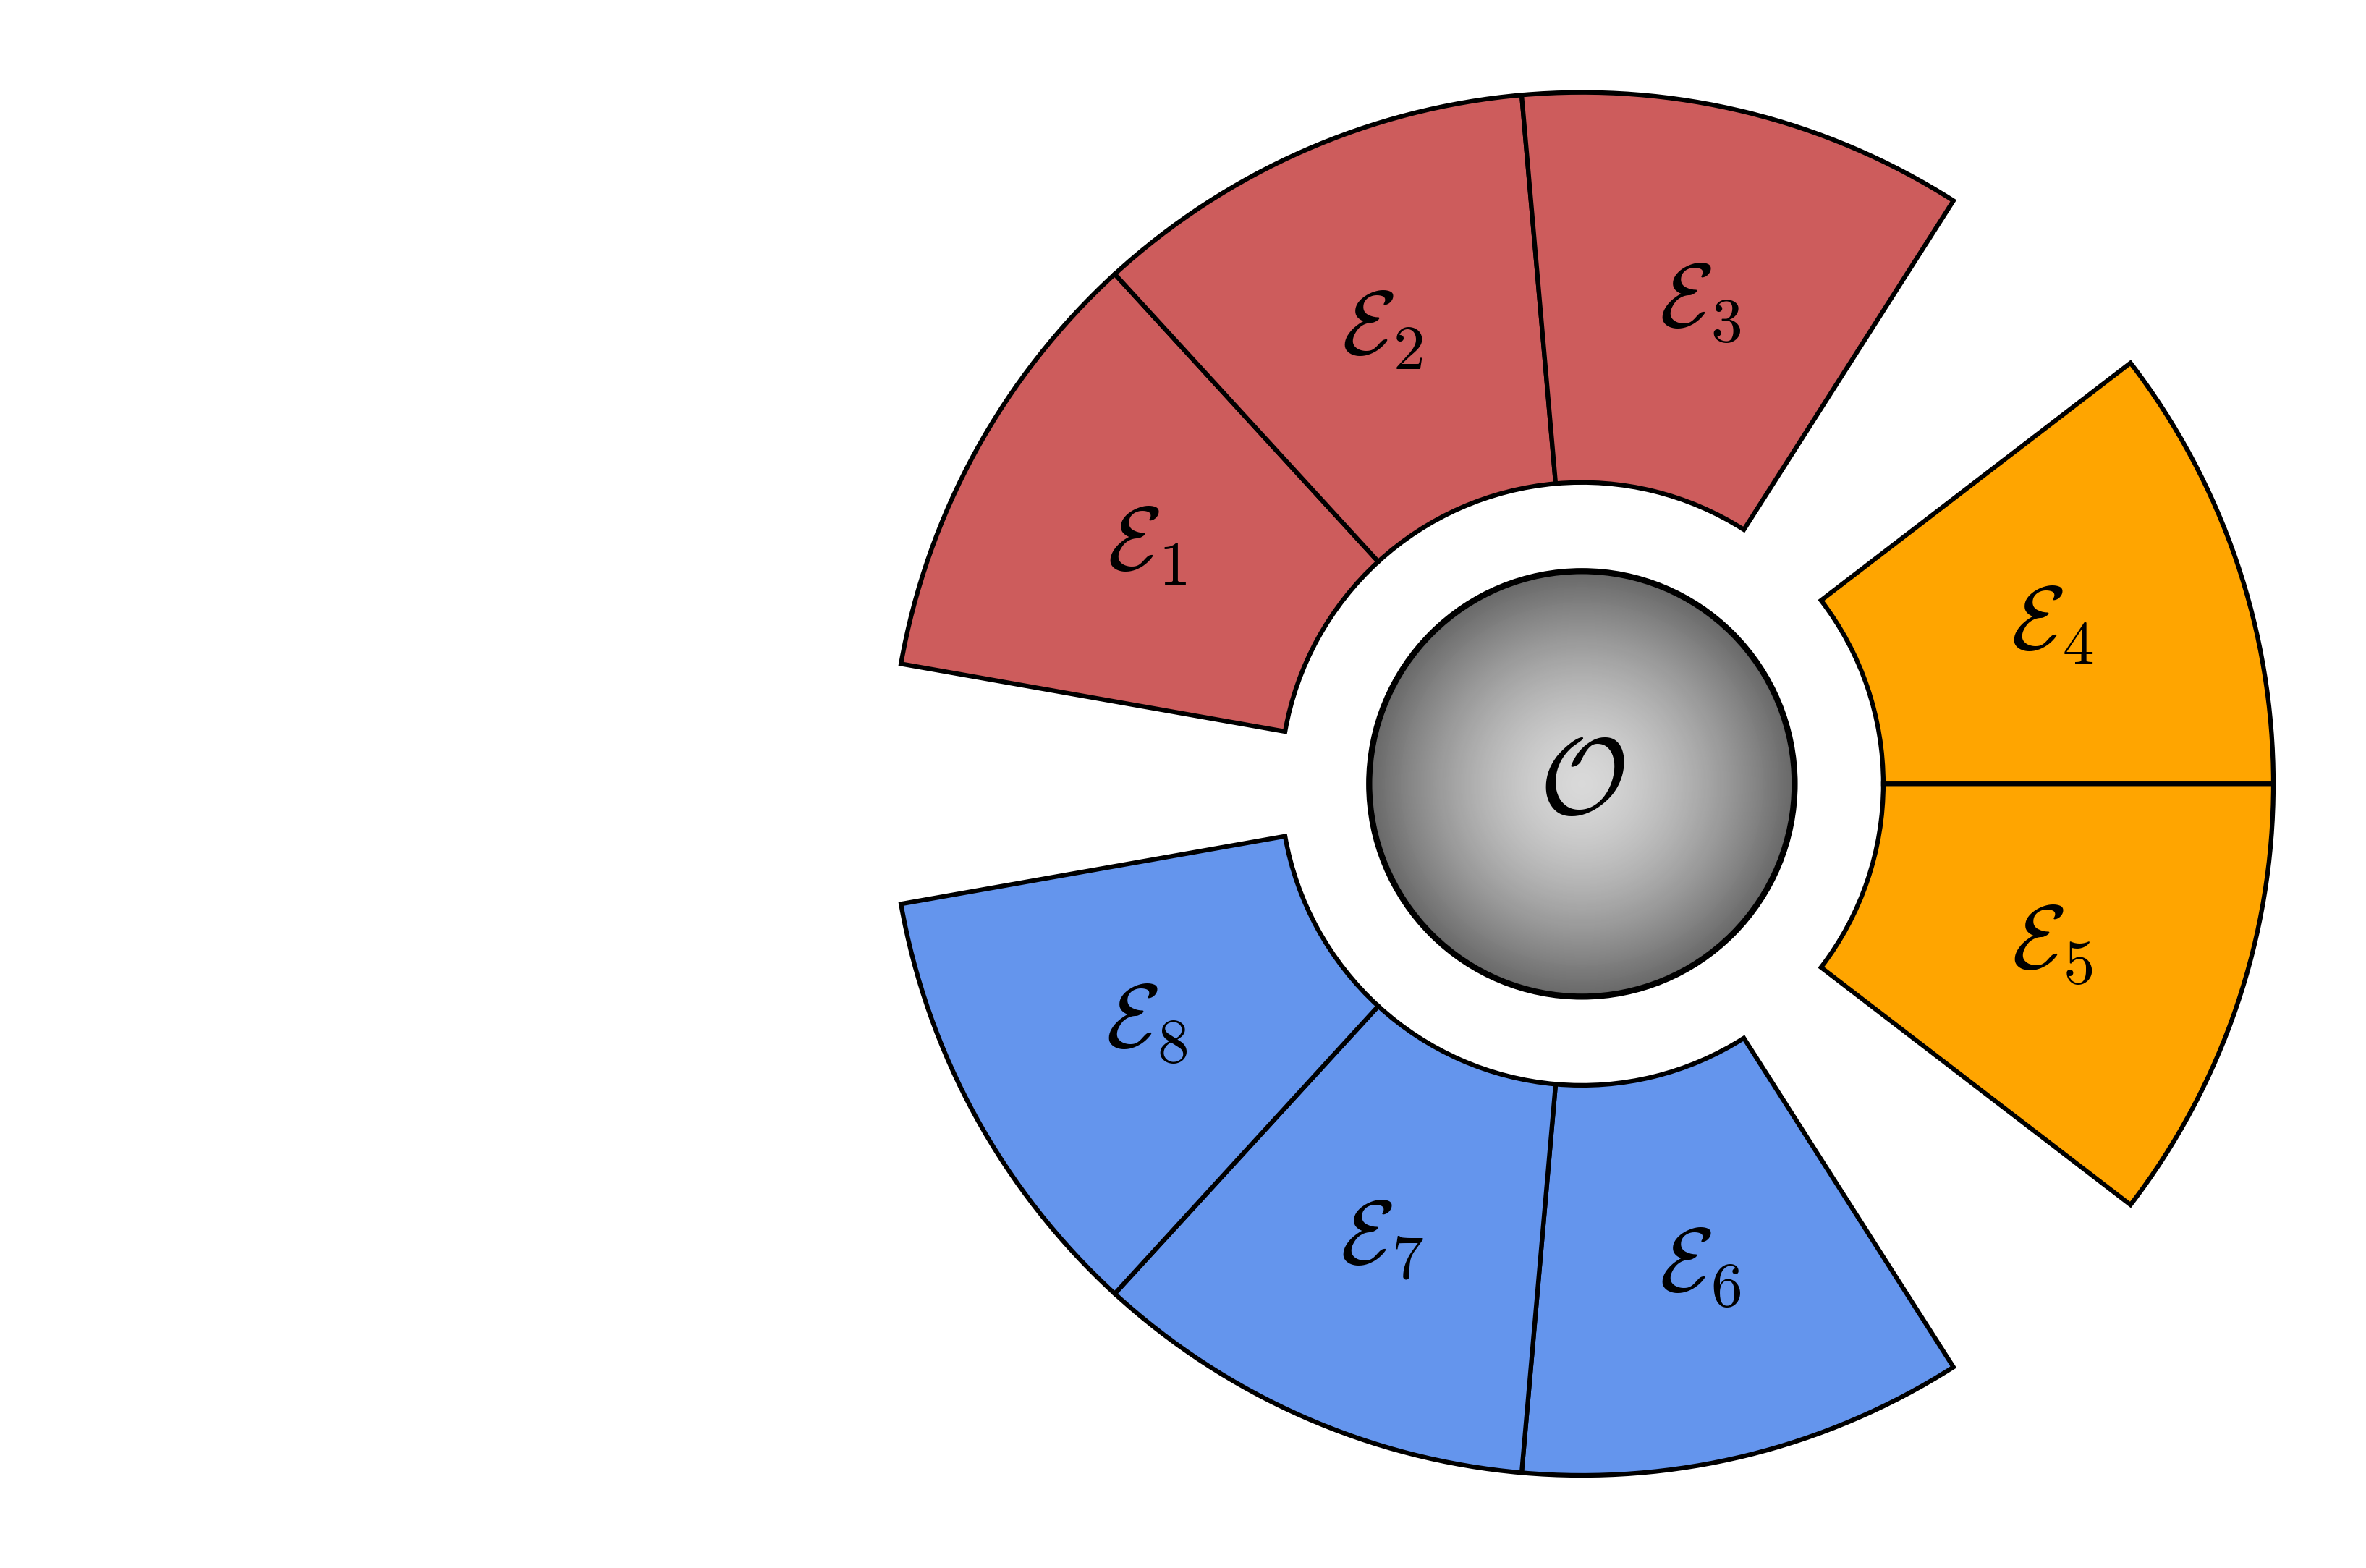

In [55]:
# QD - Zurek Picture Illustration 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle

# Cấu hình phông chữ LaTeX (Computer Modern)
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'figure.facecolor': 'white'
})

fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

# ==========================================
# THIẾT LẬP KÍCH THƯỚC VÀ KHOẢNG CÁCH
# ==========================================
r_object = 0.60                      # Bán kính đối tượng O trung tâm
radial_gap = 0.25                    # Khoảng cách từ O đến môi trường E
r_inner_env = r_object + radial_gap  # Bán kính trong môi trường E
r_outer_env = 1.95                   # Bán kính ngoài môi trường E

# Cấu hình 3 CỤM MÔI TRƯỜNG E (Tổng = 8 mảnh)
clusters = [3, 2, 3]                 # Cụm 1 (Đỏ): 3 mảnh, Cụm 2 (Vàng): 2 mảnh, Cụm 3 (Xanh): 3 mảnh
cluster_gap_deg = 20                 # Góc hở (độ) giữa các cụm

# Màu sắc theo thứ tự từ trái sang phải
cluster_colors = ['indianred', 'orange', 'cornflowerblue']

total_gaps_deg = len(clusters) * cluster_gap_deg
total_fragments = sum(clusters)
slice_angle = (360 - total_gaps_deg) / total_fragments  # ~32.5 độ/mảnh

# Tọa độ vị trí cho hình tròn S (đặt bên trái, x_S < 0)
x_S, y_S = -3.5, 0.0                 # Tâm hình tròn S bên trái
r_S = 0.60                           # Bán kính hình tròn S

# ==========================================
# 1. VẼ 3 CỤM MÔI TRƯỜNG VỚI MÀU SẮC & THỨ TỰ TỪ TRÁI SANG PHẢI
# ==========================================
# Bắt đầu vẽ từ cụm đỏ ở phía trên bên trái (sau khe hở phía trái 180 độ)
# Đi theo chiều kim đồng hồ để xếp thứ tự mảnh từ trái sang phải (từ góc ~170° giảm dần về góc tiêu chuẩn)
start_angle = 180 - cluster_gap_deg / 2
current_angle = start_angle

fragment_counter = 1

for cluster_idx, num_frags in enumerate(clusters):
    current_color = cluster_colors[cluster_idx]
    
    for i in range(num_frags):
        theta1 = current_angle - slice_angle
        theta2 = current_angle
        
        # Vẽ miếng vành khăn với màu theo cụm
        wedge = Wedge(
            center=(0, 0), r=r_outer_env, theta1=theta1, theta2=theta2, 
            width=r_outer_env - r_inner_env,
            facecolor=current_color, edgecolor='black', linewidth=1.5, zorder=1
        )
        ax.add_patch(wedge)
        
        # Tính vị trí và ghi nhãn \mathcal{E}_i
        angle_mid = np.radians((theta1 + theta2) / 2)
        r_label = (r_inner_env + r_outer_env) / 2
        x_lbl = r_label * np.cos(angle_mid)
        y_lbl = r_label * np.sin(angle_mid)
        
        ax.text(
            x_lbl, y_lbl, rf'$\mathcal{{E}}_{{{fragment_counter}}}$', 
            fontsize=30, fontweight='bold', color='black',
            ha='center', va='center', zorder=4
        )
        
        current_angle -= slice_angle
        fragment_counter += 1
        
    # Tạo khe hở góc sau mỗi cụm
    current_angle -= cluster_gap_deg

# ==========================================
# 2. VẼ ĐƯỜNG NẰM NGANG NỐI S VÀ O
# ==========================================


# ==========================================
# 3. VẼ HÌNH TRÒN O VÀ S (GRADIENT XÁM 3D)
# ==========================================
def draw_gradient_circle(center_x, center_y, radius, z_base):
    N = 150
    for r in np.linspace(0, radius, N)[::-1]:
        gray_val = 0.85 - 0.45 * (r / radius)**1.5
        circle = Circle((center_x, center_y), r, color=(gray_val, gray_val, gray_val), zorder=z_base)
        ax.add_patch(circle)
    border = Circle((center_x, center_y), radius, fill=False, edgecolor='black', linewidth=2.0, zorder=z_base+1)
    ax.add_patch(border)

# Vẽ O tại gốc tọa độ (0,0)
draw_gradient_circle(0, 0, r_object, z_base=2)
ax.text(0, 0, r'$\mathcal{O}$', fontsize=36, fontstyle='italic', ha='center', va='center', zorder=5)


# ==========================================
# 4. CẤU HÌNH CỬA SỔ HÌNH VẼ
# ==========================================
ax.set_xlim(x_S - r_S - 0.3, r_outer_env + 0.2)
ax.set_ylim(-r_outer_env - 0.2, r_outer_env + 0.2)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.savefig("QD_Zurek_Illustration.eps", dpi=600, bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


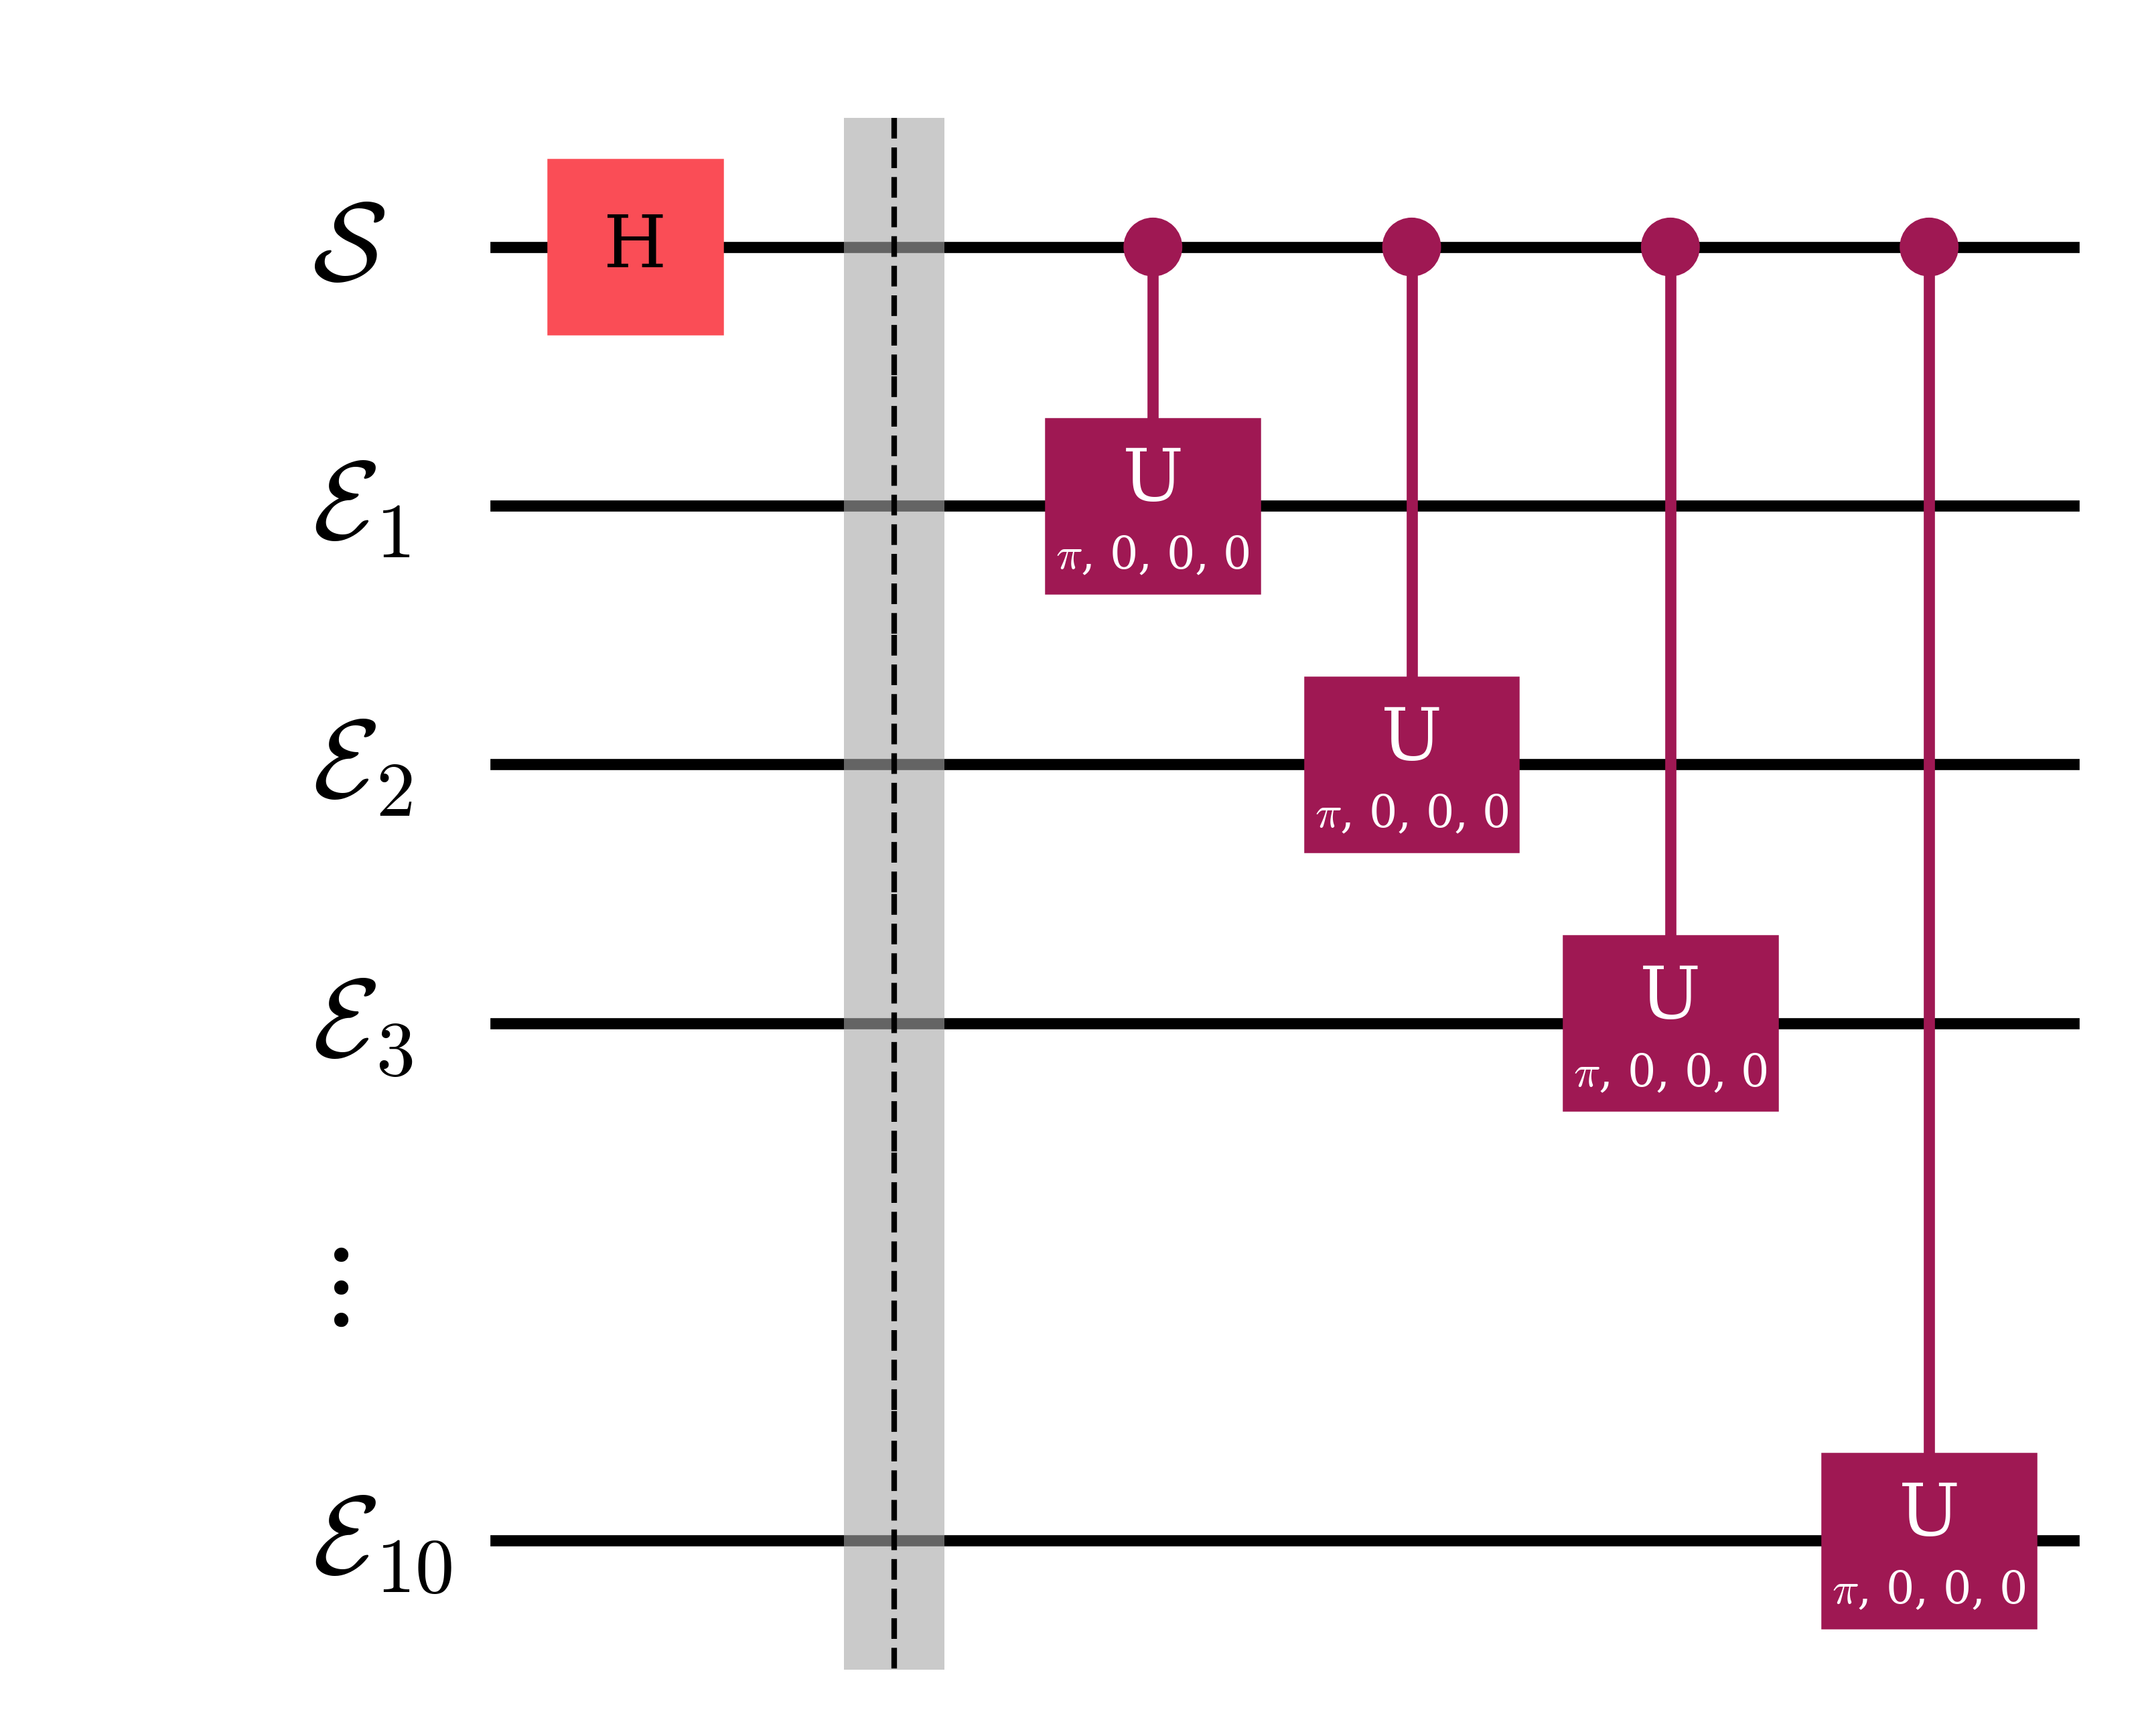

In [56]:
# QC-Zurek 
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit import Parameter
from qiskit.circuit.library import UGate

# Thiết lập độ phân giải cao cho hình ảnh
mpl.rcParams['figure.dpi'] = 600

# Khai báo các thanh ghi (giữ tên phân biệt để tránh lỗi trùng tên)
q0 = QuantumRegister(1, 'q0')
q1 = QuantumRegister(1, 'q1')
q2 = QuantumRegister(1, 'q2')
q3 = QuantumRegister(1, 'q3')
qdots = QuantumRegister(1, 'qdots')
q11 = QuantumRegister(1, 'q11')

# Khởi tạo mạch
qc = QuantumCircuit(q0, q1, q2, q3, qdots, q11)

# Khối khởi tạo
qc.h(q0)
qc.barrier()

# Khối tương tác môi trường
u3_gate = UGate(np.pi, 0, 0, label="U").control(1)
qc.append(u3_gate, [q0, q1])
qc.append(u3_gate, [q0, q2])
qc.append(u3_gate, [q0, q3])
qc.append(u3_gate, [q0, q11])

# 1. Vẽ mạch từ Qiskit bằng MPL backend
fig = qc.draw(output="mpl", idle_wires=True)
ax = fig.axes[0]

# 2. Xử lý các nhãn gốc: ẩn văn bản và xóa hộp bbox
original_y_coords = []
for text in ax.texts:
    x, y = text.get_position()
    # Các nhãn qubit luôn nằm bên trái dây (x < 0)
    if x < 0:
        original_y_coords.append(y)
        # Ẩn văn bản cũ
        text.set_visible(False)
        # !!! SỬA LỖI TẠI ĐÂY !!!
        # Xóa bỏ hộp bbox mặc định để nó không đè lên chữ mới
        text.set_bbox(dict(facecolor='none', edgecolor='none', alpha=0.0))

# Sắp xếp tọa độ y thực tế từ trên xuống dưới
original_y_coords = sorted(original_y_coords, reverse=True)

# 3. Danh sách nhãn LaTeX theo đúng thứ tự: S -> E1 -> E2 -> E3 -> ⋮ -> E11
latex_labels = [
    r'$\mathcal{S}$',
    r'$\mathcal{E}_1$',
    r'$\mathcal{E}_2$',
    r'$\mathcal{E}_3$',
    r'$\vdots$',
    r'$\mathcal{E}_{10}$'
]

# 4. Ghi đè nhãn LaTeX mới vào đúng tọa độ y của từng dây
# Tinh chỉnh độ cao bằng y_offset nếu cần (ví dụ -0.05)
y_offset = -0.01
y_dots = original_y_coords[4]
x_offset = -0.95  # Dịch sang trái để tránh trùng với dây
for line in ax.lines:
    ydata = line.get_ydata()
    if len(ydata) > 0 and all(np.isclose(y, y_dots) for y in ydata):
        line.set_visible(False)  # Ẩn hoàn toàn wire
for y_pos, label in zip(original_y_coords, latex_labels):
    # Dấu 3 chấm đứng nhích nhẹ sang phải cho thẳng hàng với chữ E
    x_pos = x_offset if label == r'$\vdots$' else x_offset
    
    ax.text(
        x_pos, y_pos + y_offset, label,
        fontsize=20,
        ha='left', # Căn lề phải
        va='center', # Căn giữa theo chiều dọc
        color='black',
        zorder=100  # Đảm bảo chữ luôn nằm trên cùng
    )
fig.savefig("QD_Zurek.eps", dpi=600, bbox_inches='tight')
# Hiển thị hình
fig

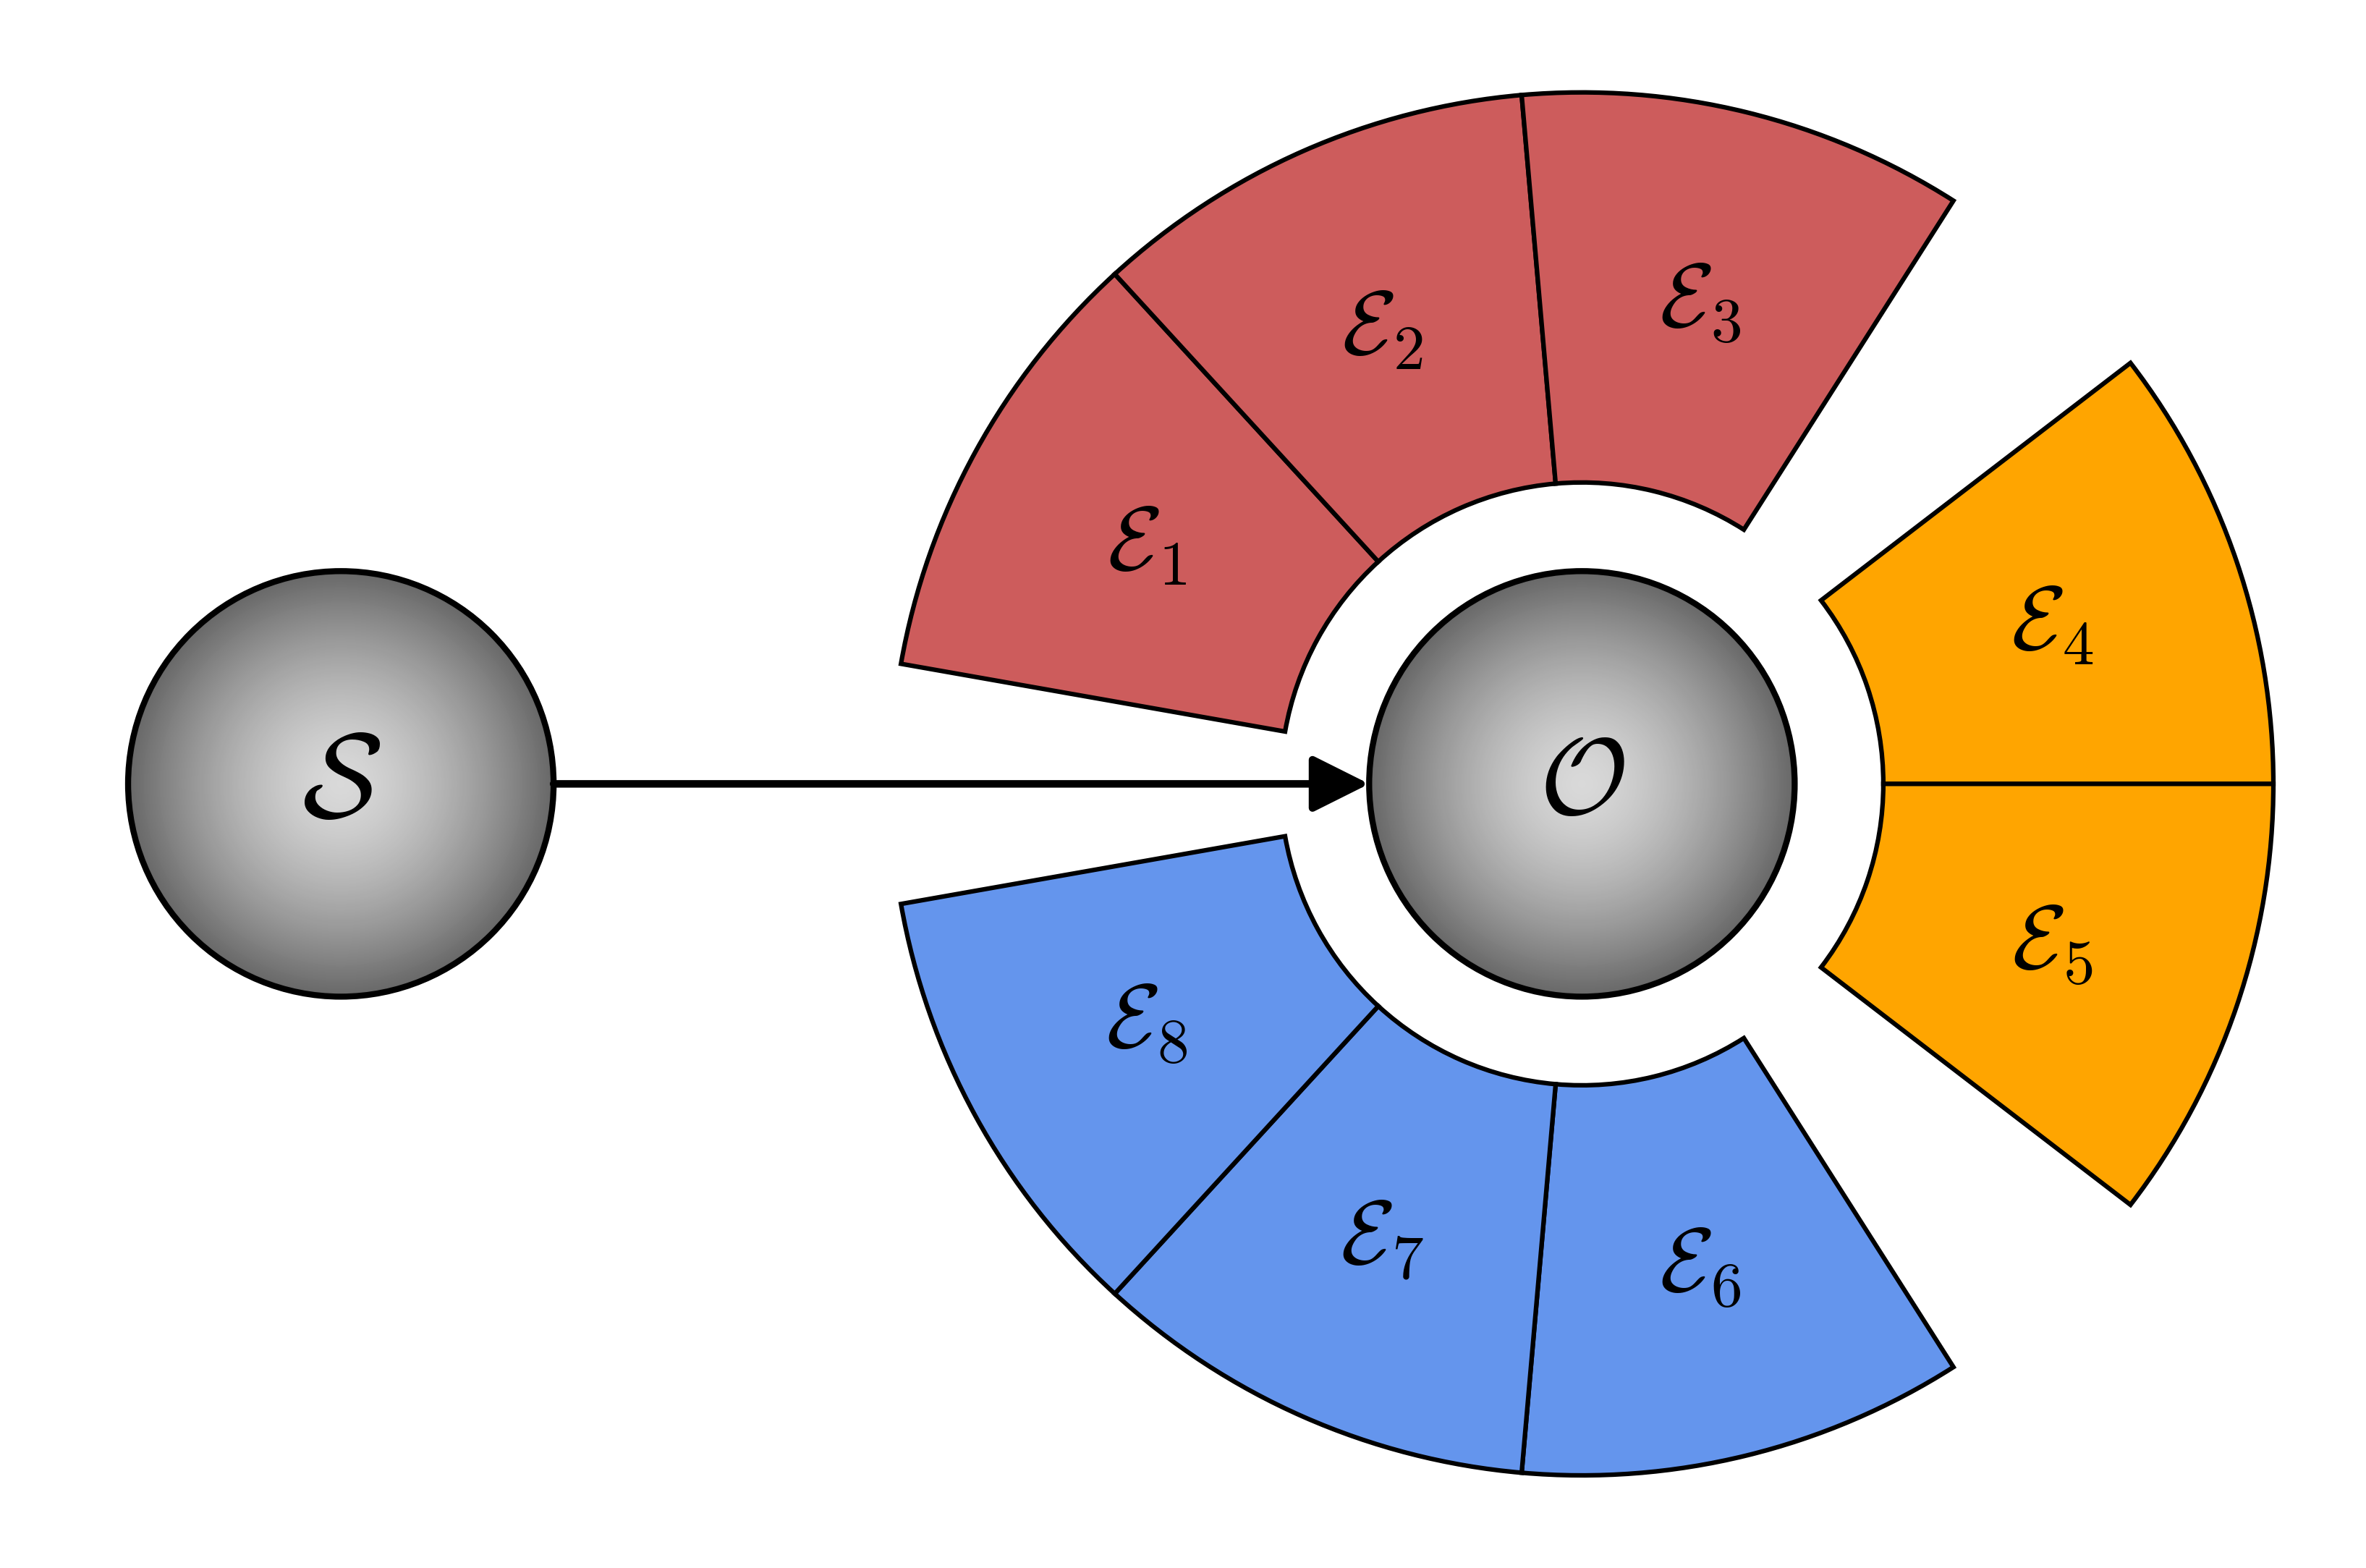

In [57]:
# QD - Wigner Picture Illustration 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle

# Cấu hình phông chữ LaTeX (Computer Modern)
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'figure.facecolor': 'white'
})

fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

# ==========================================
# THIẾT LẬP KÍCH THƯỚC VÀ KHOẢNG CÁCH
# ==========================================
r_object = 0.60                      # Bán kính đối tượng O trung tâm
radial_gap = 0.25                    # Khoảng cách từ O đến môi trường E
r_inner_env = r_object + radial_gap  # Bán kính trong môi trường E
r_outer_env = 1.95                   # Bán kính ngoài môi trường E

# Cấu hình 3 CỤM MÔI TRƯỜNG E (Tổng = 8 mảnh)
clusters = [3, 2, 3]                 # Cụm 1 (Đỏ): 3 mảnh, Cụm 2 (Vàng): 2 mảnh, Cụm 3 (Xanh): 3 mảnh
cluster_gap_deg = 20                 # Góc hở (độ) giữa các cụm

# Màu sắc theo thứ tự từ trái sang phải
cluster_colors = ['indianred', 'orange', 'cornflowerblue']

total_gaps_deg = len(clusters) * cluster_gap_deg
total_fragments = sum(clusters)
slice_angle = (360 - total_gaps_deg) / total_fragments  # ~32.5 độ/mảnh

# Tọa độ vị trí cho hình tròn S (đặt bên trái, x_S < 0)
x_S, y_S = -3.5, 0.0                 # Tâm hình tròn S bên trái
r_S = 0.60                           # Bán kính hình tròn S

# ==========================================
# 1. VẼ 3 CỤM MÔI TRƯỜNG VỚI MÀU SẮC & THỨ TỰ TỪ TRÁI SANG PHẢI
# ==========================================
# Bắt đầu vẽ từ cụm đỏ ở phía trên bên trái (sau khe hở phía trái 180 độ)
# Đi theo chiều kim đồng hồ để xếp thứ tự mảnh từ trái sang phải (từ góc ~170° giảm dần về góc tiêu chuẩn)
start_angle = 180 - cluster_gap_deg / 2
current_angle = start_angle

fragment_counter = 1

for cluster_idx, num_frags in enumerate(clusters):
    current_color = cluster_colors[cluster_idx]
    
    for i in range(num_frags):
        theta1 = current_angle - slice_angle
        theta2 = current_angle
        
        # Vẽ miếng vành khăn với màu theo cụm
        wedge = Wedge(
            center=(0, 0), r=r_outer_env, theta1=theta1, theta2=theta2, 
            width=r_outer_env - r_inner_env,
            facecolor=current_color, edgecolor='black', linewidth=1.5, zorder=1
        )
        ax.add_patch(wedge)
        
        # Tính vị trí và ghi nhãn \mathcal{E}_i
        angle_mid = np.radians((theta1 + theta2) / 2)
        r_label = (r_inner_env + r_outer_env) / 2
        x_lbl = r_label * np.cos(angle_mid)
        y_lbl = r_label * np.sin(angle_mid)
        
        ax.text(
            x_lbl, y_lbl, rf'$\mathcal{{E}}_{{{fragment_counter}}}$', 
            fontsize=30, fontweight='bold', color='black',
            ha='center', va='center', zorder=4
        )
        
        current_angle -= slice_angle
        fragment_counter += 1
        
    # Tạo khe hở góc sau mỗi cụm
    current_angle -= cluster_gap_deg

# ==========================================
# 2. VẼ ĐƯỜNG NẰM NGANG NỐI S VÀ O
# ==========================================
# Mũi tên từ S tới O qua khe hở phía trái
ax.annotate('', xy=(-r_object, 0), xytext=(x_S + r_S, 0),
            arrowprops=dict(arrowstyle='- |>', mutation_scale=40, color='black',
                            lw=2.5, shrinkA=0, shrinkB=0), zorder=3)

# ==========================================
# 3. VẼ HÌNH TRÒN O VÀ S (GRADIENT XÁM 3D)
# ==========================================
def draw_gradient_circle(center_x, center_y, radius, z_base):
    N = 150
    for r in np.linspace(0, radius, N)[::-1]:
        gray_val = 0.85 - 0.45 * (r / radius)**1.5
        circle = Circle((center_x, center_y), r, color=(gray_val, gray_val, gray_val), zorder=z_base)
        ax.add_patch(circle)
    border = Circle((center_x, center_y), radius, fill=False, edgecolor='black', linewidth=2.0, zorder=z_base+1)
    ax.add_patch(border)

# Vẽ O tại gốc tọa độ (0,0)
draw_gradient_circle(0, 0, r_object, z_base=2)
ax.text(0, 0, r'$\mathcal{O}$', fontsize=36, fontstyle='italic', ha='center', va='center', zorder=5)

# Vẽ S bên trái (-3.5, 0)
draw_gradient_circle(x_S, y_S, r_S, z_base=2)
ax.text(x_S, y_S, r'$\mathcal{S}$', fontsize=40, fontstyle='italic', ha='center', va='center', zorder=5)

# ==========================================
# 4. CẤU HÌNH CỬA SỔ HÌNH VẼ
# ==========================================
ax.set_xlim(x_S - r_S - 0.3, r_outer_env + 0.2)
ax.set_ylim(-r_outer_env - 0.2, r_outer_env + 0.2)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.savefig("QD_Wigner_Illustration.eps", dpi=600, bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


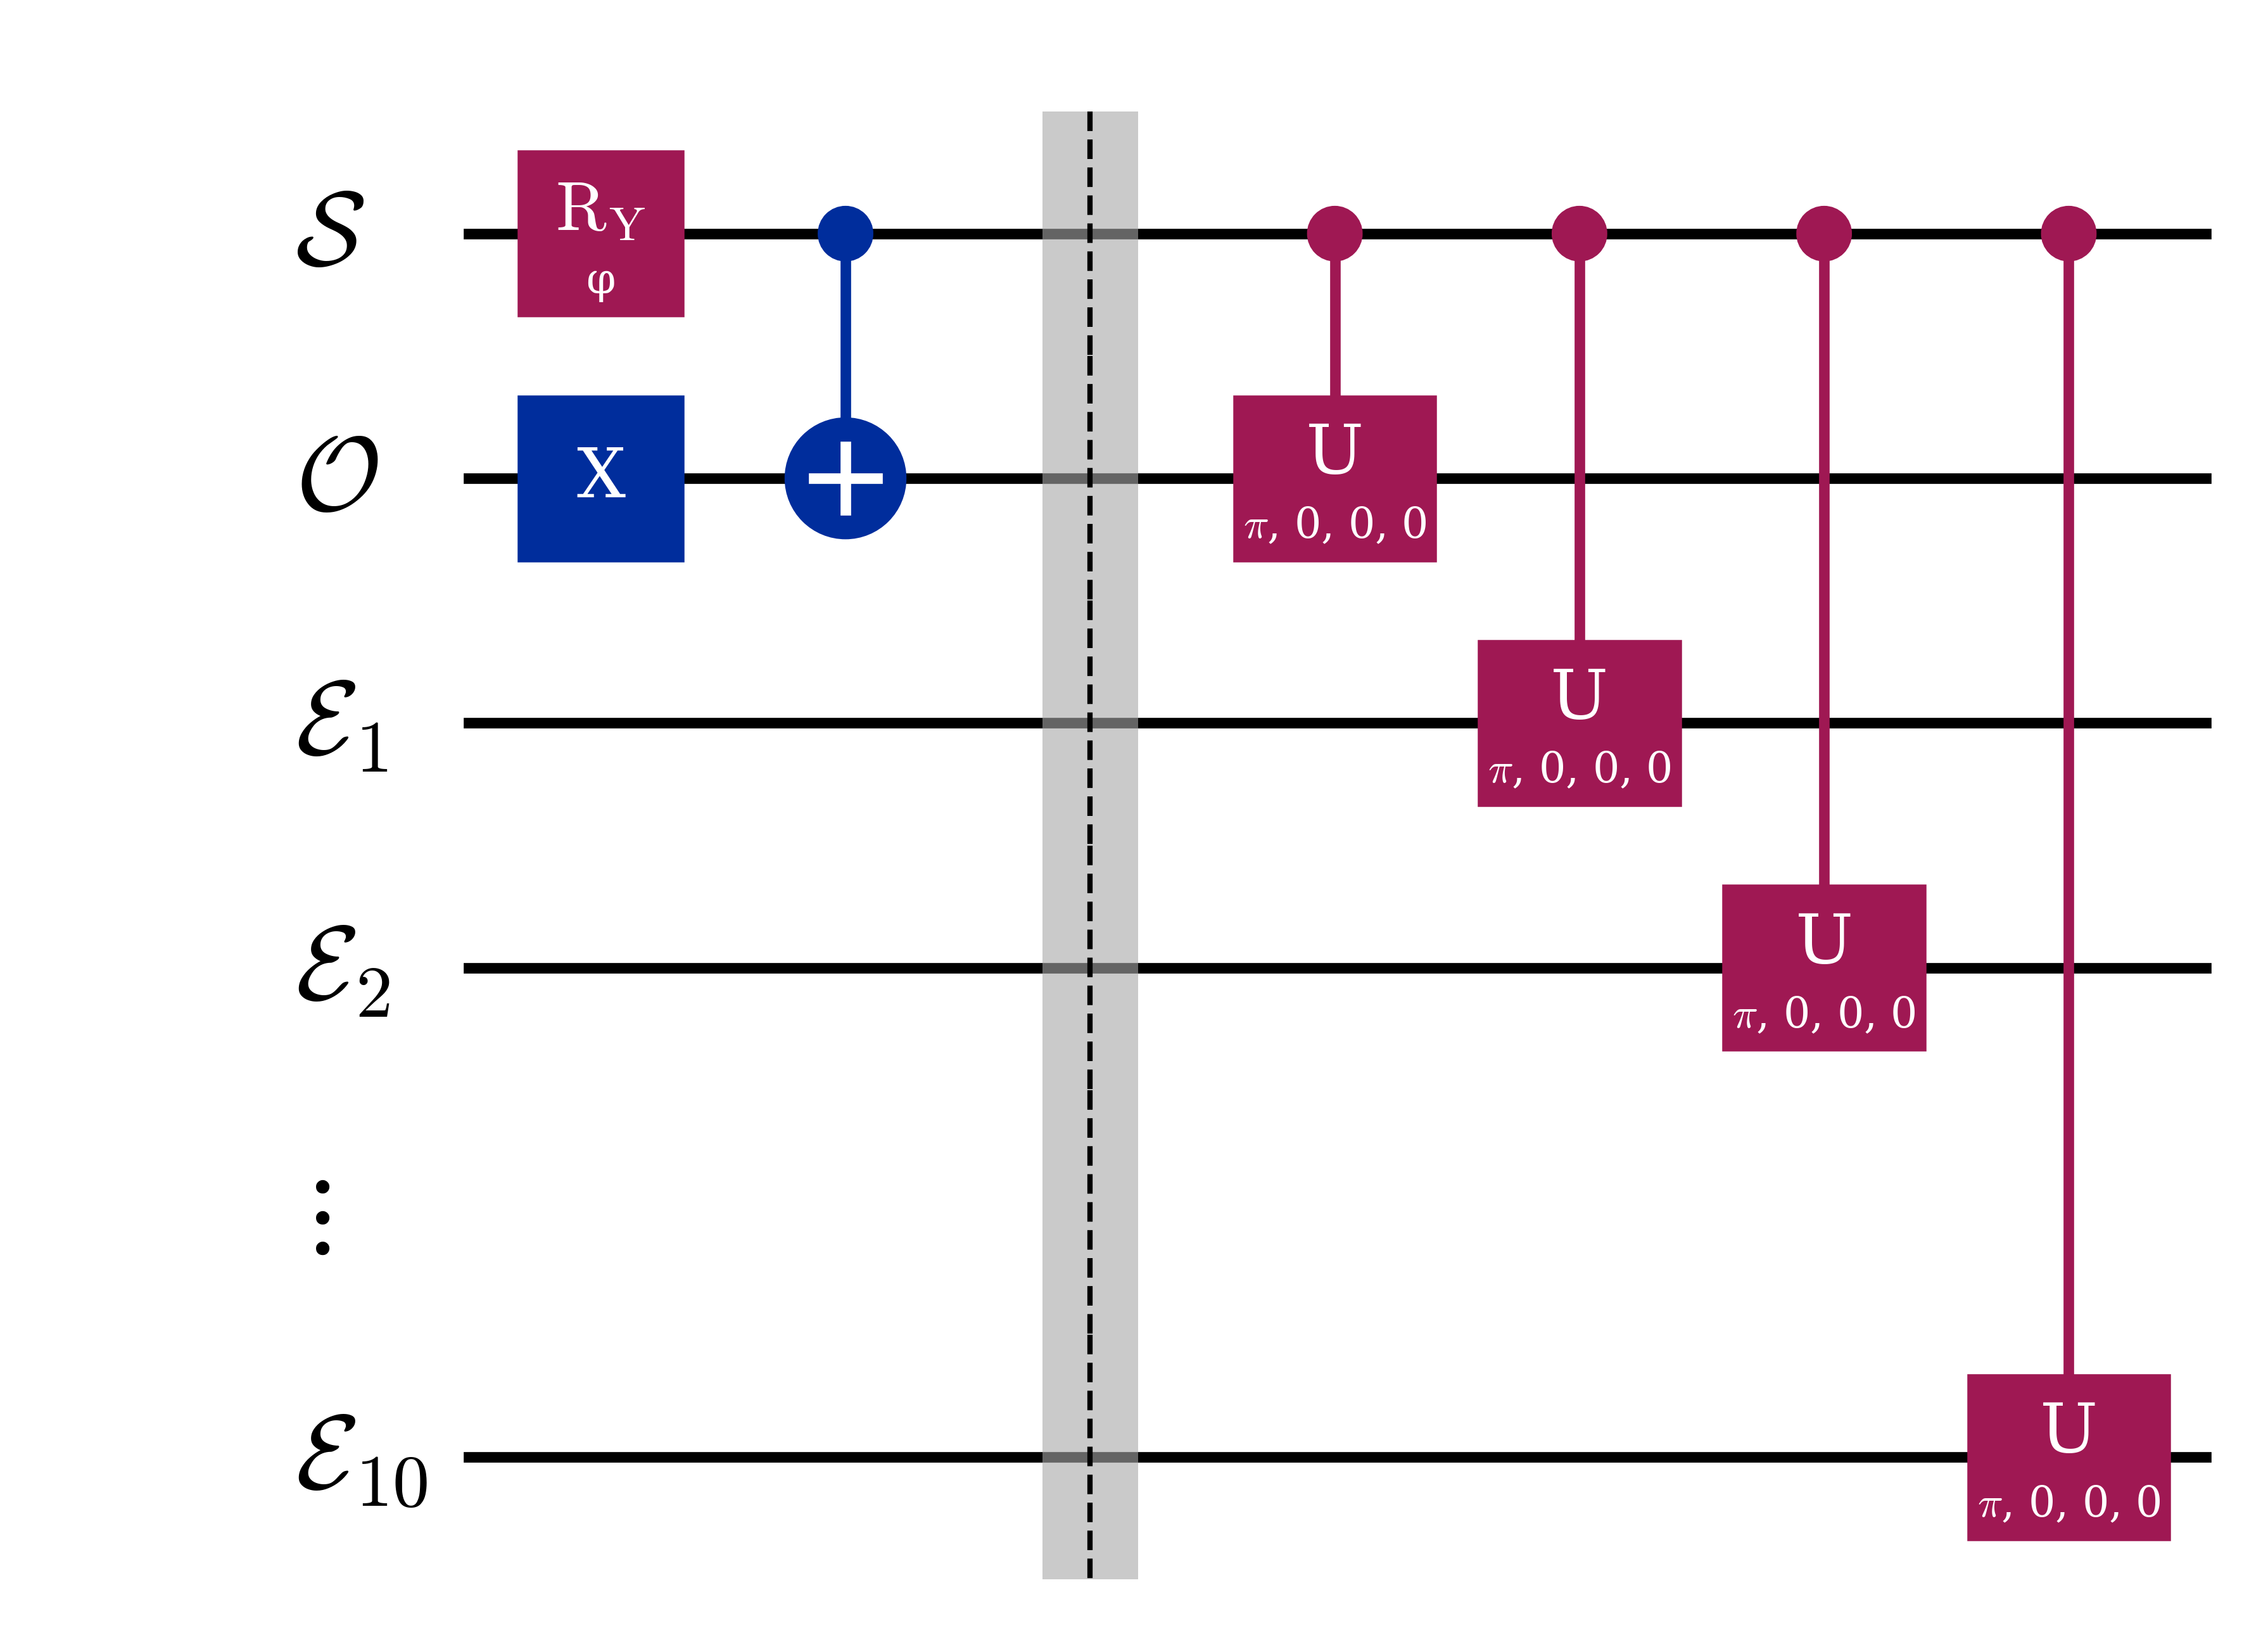

In [58]:
# QC-Wigner
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit import Parameter
from qiskit.circuit.library import UGate

# Thiết lập độ phân giải cao cho hình ảnh
mpl.rcParams['figure.dpi'] = 600
phi = Parameter('φ')

# Khai báo các thanh ghi (giữ tên phân biệt để tránh lỗi trùng tên)
q0 = QuantumRegister(1, 'q0') # System
q1 = QuantumRegister(1, 'q1') # Observer
q2 = QuantumRegister(1, 'q2') # environment
q3 = QuantumRegister(1, 'q3')
q4 = QuantumRegister(1, 'q4')
qdots = QuantumRegister(1, 'qdots')
q12 = QuantumRegister(1, 'q12')

# Khởi tạo mạch
qc = QuantumCircuit(q0, q1, q2, q3, qdots, q12)

# Khối khởi tạo
qc.ry(phi, q0)
qc.x(q1)
qc.cx(q0, q1)
qc.barrier()

# Khối tương tác môi trường
u3_gate = UGate(np.pi, 0, 0, label="U").control(1)
qc.append(u3_gate, [q0, q1])
qc.append(u3_gate, [q0, q2])
qc.append(u3_gate, [q0, q3])
qc.append(u3_gate, [q0, q12])

# 1. Vẽ mạch từ Qiskit bằng MPL backend
fig = qc.draw(output="mpl", idle_wires=True)
ax = fig.axes[0]

# 2. Xử lý các nhãn gốc: ẩn văn bản và xóa hộp bbox
original_y_coords = []
for text in ax.texts:
    x, y = text.get_position()
    # Các nhãn qubit luôn nằm bên trái dây (x < 0)
    if x < 0:
        original_y_coords.append(y)
        # Ẩn văn bản cũ
        text.set_visible(False)
        # !!! SỬA LỖI TẠI ĐÂY !!!
        # Xóa bỏ hộp bbox mặc định để nó không đè lên chữ mới
        text.set_bbox(dict(facecolor='none', edgecolor='none', alpha=0.0))

# Sắp xếp tọa độ y thực tế từ trên xuống dưới
original_y_coords = sorted(original_y_coords, reverse=True)

# 3. Danh sách nhãn LaTeX theo đúng thứ tự: S -> E1 -> E2 -> E3 -> ⋮ -> E11
latex_labels = [
    r'$\mathcal{S}$',
    r'$\mathcal{O}$',
    r'$\mathcal{E}_1$',
    r'$\mathcal{E}_2$',
    r'$\vdots$',
    r'$\mathcal{E}_{10}$'
]

# 4. Ghi đè nhãn LaTeX mới vào đúng tọa độ y của từng dây
# Tinh chỉnh độ cao bằng y_offset nếu cần (ví dụ -0.05)
y_offset = -0.01
y_dots = original_y_coords[4]
x_offset = -0.95  # Dịch sang trái để tránh trùng với dây
for line in ax.lines:
    ydata = line.get_ydata()
    if len(ydata) > 0 and all(np.isclose(y, y_dots) for y in ydata):
        line.set_visible(False)  # Ẩn hoàn toàn wire
for y_pos, label in zip(original_y_coords, latex_labels):
    # Dấu 3 chấm đứng nhích nhẹ sang phải cho thẳng hàng với chữ E
    x_pos = x_offset if label == r'$\vdots$' else x_offset
    
    ax.text(
        x_pos, y_pos + y_offset, label,
        fontsize=20,
        ha='left', # Căn lề phải
        va='center', # Căn giữa theo chiều dọc
        color='black',
        zorder=100  # Đảm bảo chữ luôn nằm trên cùng
    )
fig.savefig("QD_Wigner.eps", dpi=600, bbox_inches='tight')
# Hiển thị hình
fig